# Flood Risk Prediction

# FLOOD RISK PREDICTION

## 1.Problem Definition
Flooding is one of the most devastating natural disasters, often resulting in loss of life, displacement, and destruction of property and infrastructure. Accurate and timely flood risk prediction is critical for disaster preparedness, urban planning, and climate resilience efforts. 

### Statistics
On average, floods affect at least 45,000 people annually, with some years seeing hundreds of thousands displaced. 

Deaths:
Floods have caused at least 480 deaths in recent years. In 2021, they accounted for 39% of disaster-related deaths. 

In May 2024, floods affected 39,185 people in 14 districts within 11 days.  
In November 2019, floods and landslides in Bundibugyo, Bududa, and Sironko districts resulted in at least 38 deaths and over 150 injuries, affecting an estimated 300,000 people, according to ReliefWeb.  
In April 2023, floods and landslides in Kasese, Mbale, and Rukungiri districts resulted in multiple deaths and displacement.  
In November 2023, the Uganda Red Cross Society reported 25,000 people already affected by floods and anticipated further impacts due to the El Niño period, according to Anticipation Hub. 

### Mbarara in Specific
 A notable instance occurred in March 2018 when a heavy downpour caused the Rwizi River to overflow, resulting in at least one death and damage to buildings, including a hotel under construction. 
 More recently, in May 2023, heavy rains disrupted business activities and submerged the NWSC system after the Rwizi River breached its banks, according to The Cooperator News.


## Solution
A machine learning-powered flood risk prediction system that estimates the probability of flooding in a given region based on 20+ environmental, climatic, and infrastructural indicators. By transforming complex data into real-time flood probability scores and risk categories, the model empowers governments, city planners, and disaster management teams to make data-driven decisions that minimize flood impact, enhance early warning systems, and protect vulnerable communities."


**What we shall do:**
- Problem Definition & Motivation
- Data Cleaning & Preprocessing
- Feature Engineering & Selection
- Exploratory Data Analysis (EDA) with visualizations
- Model Selection & Baseline Comparisons
- Model Training, Evaluation, and Interpretation



**Objective:** Build a regression model to predict flood probability in a region.  

**Why Regression?**  
- Directly quantifies flood-driving volume.  
- Enables threshold-based classification for flood alerts.  
- Simpler and more interpretable than direct classification on limited data.  

**Target:** `FloodPrediction` that is in continous form.  

**Features** 
- MonsoonIntensity
- TopographyDrainage
- RiverManagement
- Deforestation
- Urbanization
- ClimateChange
- DamsQuality
- Siltation
- AgriculturalPractices
- Encroachments
- IneffectiveDisasterPreparedness
- DrainageSystems
- CoastalVulnerability
- Landslides
- Watersheds
- DeterioratingInfrastructure
- PopulationScore
- WetlandLoss
- InadequatePlanning
- PoliticalFactors

In [5]:


%pip install seaborn

# ## 1. Imports & Environment Setup
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lars
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 446.7 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


## 3. Data Acquisition, Cleaning and Preprocessing

We managed to acquire a dataset from kaggle.com with sufficient information to train our model. It seemed well processed already but we decided to have our own take on it, for the sake of research and understanding the underlying principles of handling datasets for ML.

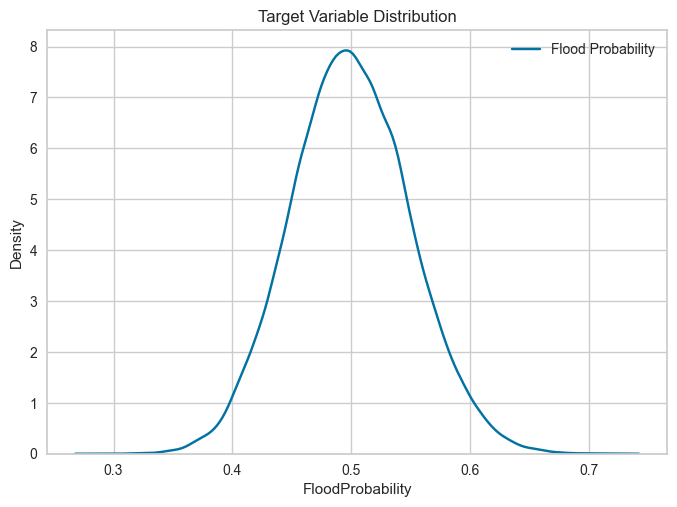

In [6]:
df = pd.read_csv('data/flood.csv')

# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Check for class imbalance in target (though continuous)
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.legend(['Flood Probability'])
plt.show()

In [ ]:
# import smogn

# # Ensure all columns are float32 for compatibility and efficiency with smogn
# df = df.astype('float32')

# relevance_config = np.array([
#     [0.4, 1.0, 0.5],
#     [0.5, 0.0, 0.5],
#     [0.6, 1.0, 0.5]
# ])

# # 2. Apply SMOGN with custom relevance
# df_smogn = smogn.smoter(
#     data=df,
#     y='FloodProbability',
#     rel_thres=0.8,
#     rel_method='manual',
#     rel_ctrl_pts_rg=relevance_config,
#     samp_method='extreme',
#     k=3
# )

# print("Original shape:", df.shape)
# print("SMOGN-balanced shape:", df_smogn.shape)

# # Use the new dataframe for training
# df = df_smogn.copy()

# sns.kdeplot(df['FloodProbability'])
# plt.title('Target Variable Distribution')
# plt.show()

### 4. Feature Engineering and Selection

In [7]:
# 1. Interaction terms (domain knowledge-based)
df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']
df['Urbanization_Encroachment'] = df['Urbanization'] * df['Encroachments']

# 2. Climate vulnerability index
climate_features = ['ClimateChange', 'CoastalVulnerability', 'WetlandLoss']
df['ClimateVulnerability'] = df[climate_features].mean(axis=1)

# 3. Infrastructure quality composite
infra_features = ['RiverManagement', 'DamsQuality', 'DrainageSystems']
df['InfrastructureQuality'] = df[infra_features].mean(axis=1)

X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Exploratory Data Analysis (EDA)

Let's visualize:
1. Basic Summary Statistics
2. Missing Values Check
3. Distribution Plots
4. Correlation Matrix
5. Pairplots / Scatterplots
Focused on top-correlated features with FloodProbability
Helps visually identify linear/nonlinear trends
6. Boxplots
Show how each feature influences FloodProbability
Detect outliers (e.g., via IQR)

Dataset Description:

       MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
count      50000.000000        50000.000000      50000.00000   50000.000000   
mean           4.991480            4.984100          5.01594       5.008480   
std            2.236834            2.246488          2.23131       2.222743   
min            0.000000            0.000000          0.00000       0.000000   
25%            3.000000            3.000000          3.00000       3.000000   
50%            5.000000            5.000000          5.00000       5.000000   
75%            6.000000            6.000000          6.00000       6.000000   
max           16.000000           18.000000         16.00000      17.000000   

       Urbanization  ClimateChange  DamsQuality     Siltation  \
count  50000.000000   50000.000000  50000.00000  50000.000000   
mean       4.989060       4.988340      5.01536      4.988600   
std        2.243159       2.226761      2.24500      2.232642   
min   

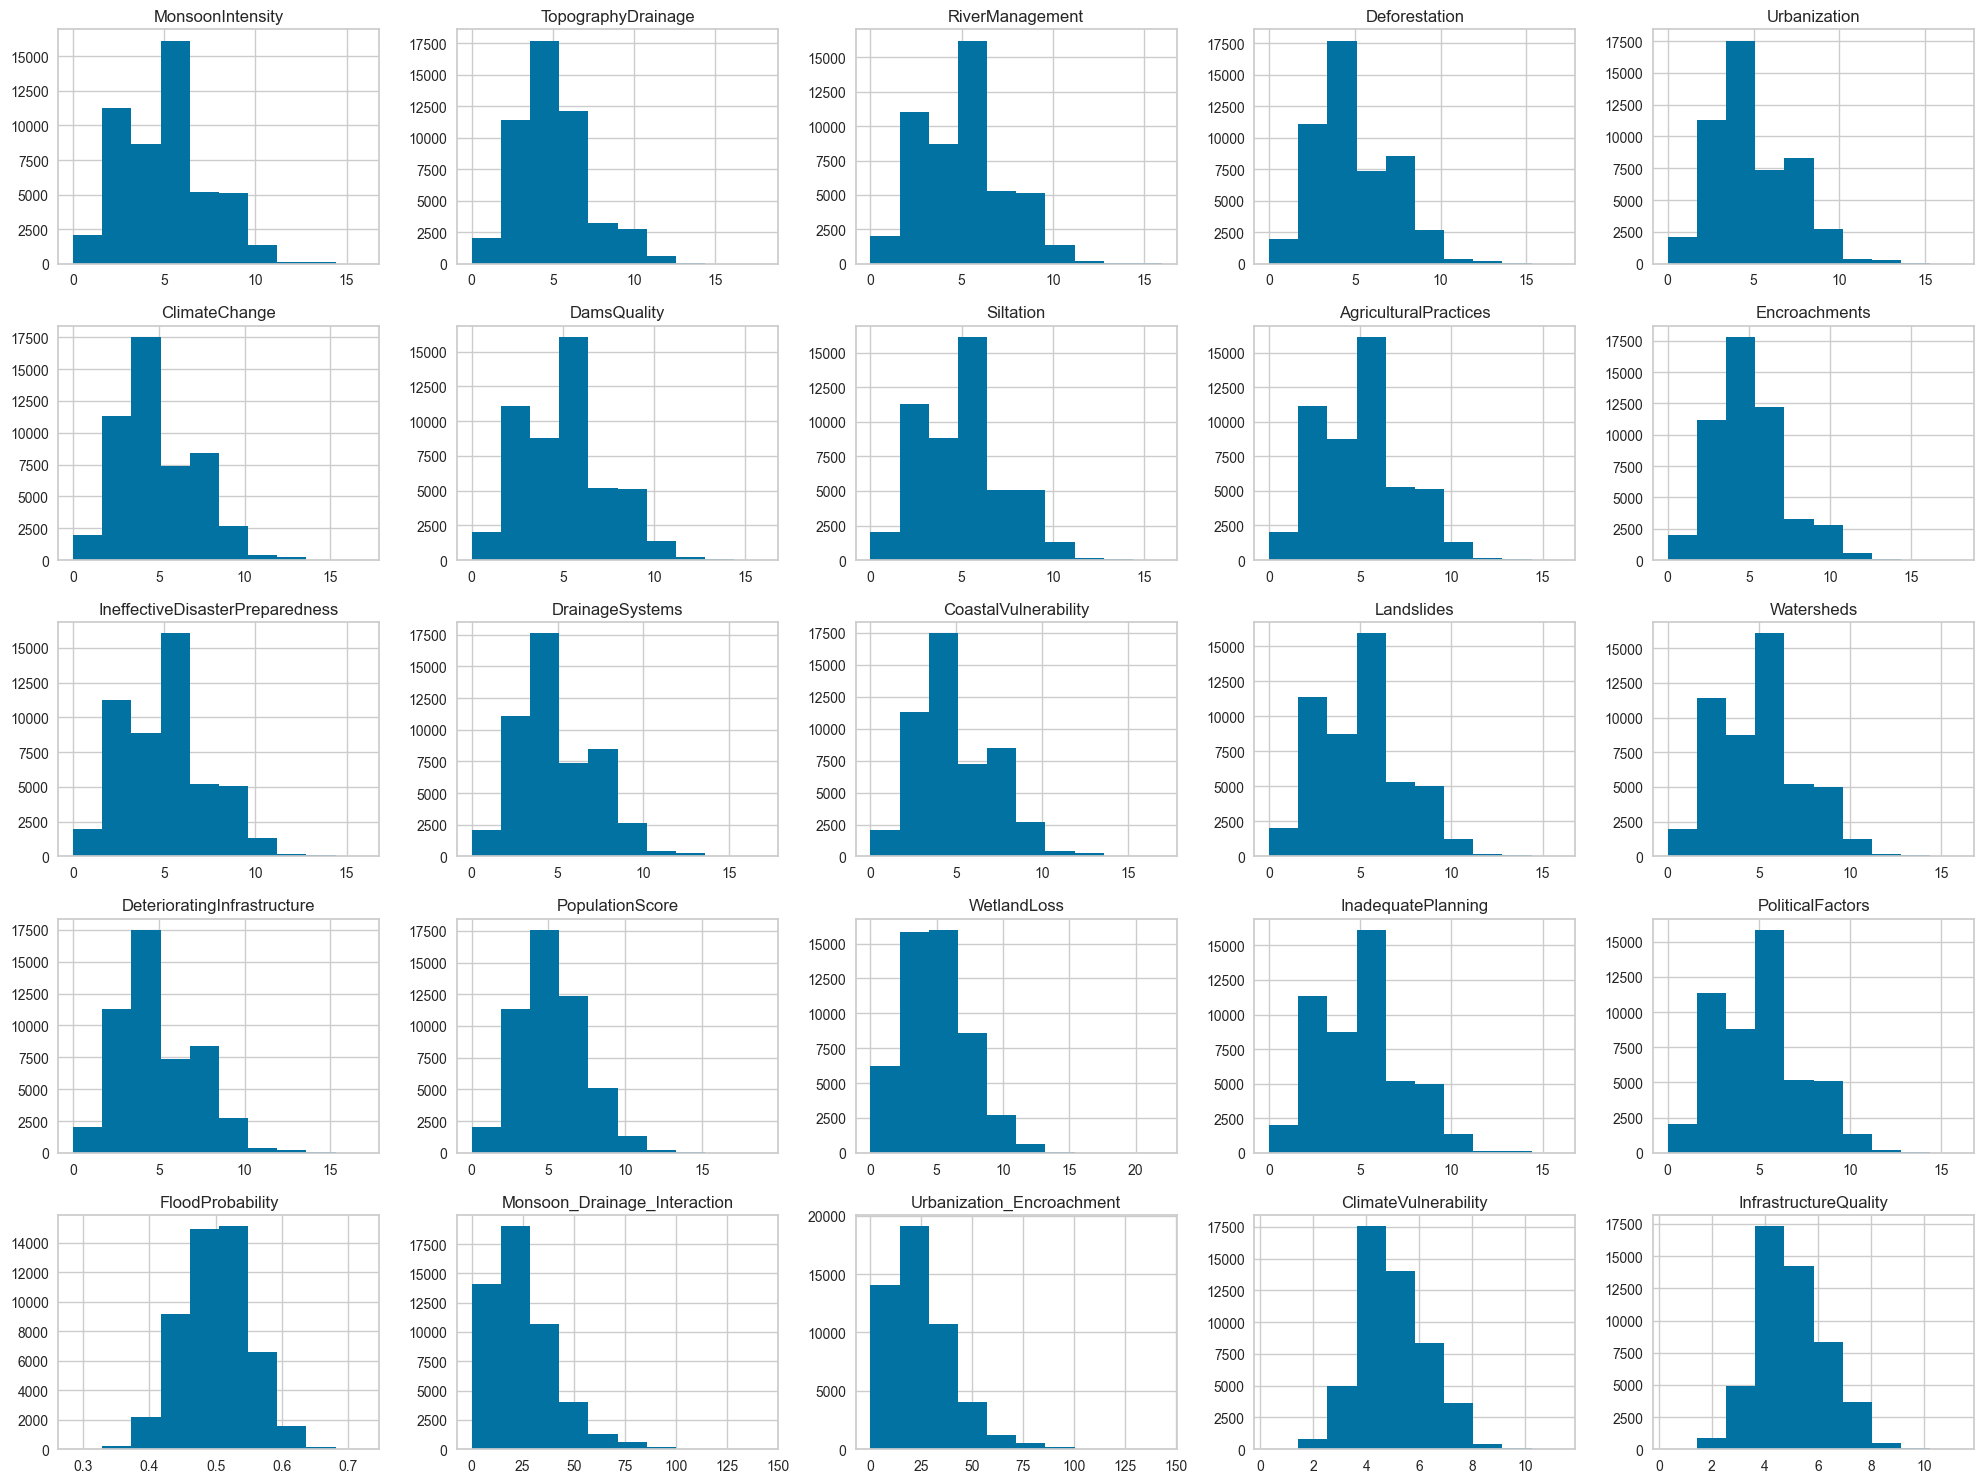

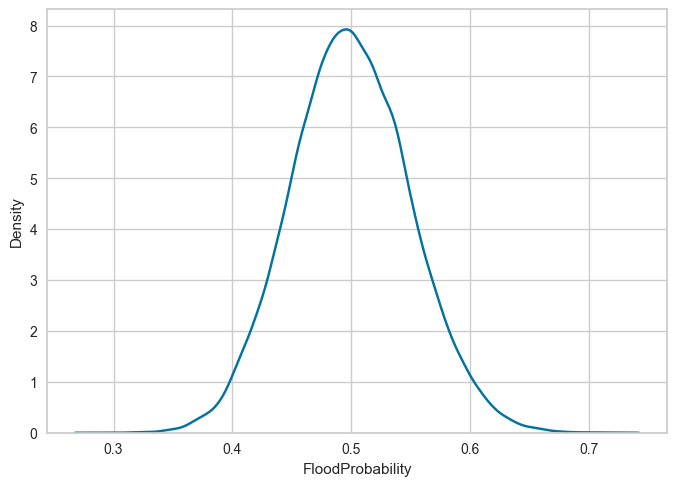

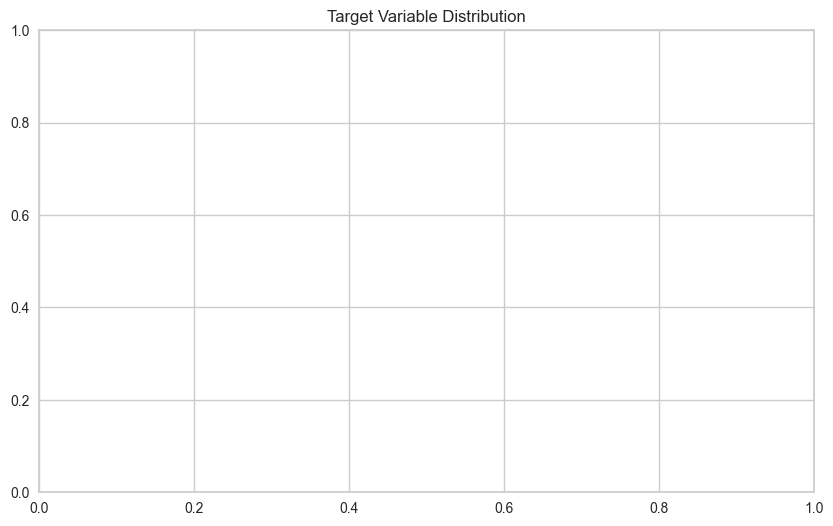

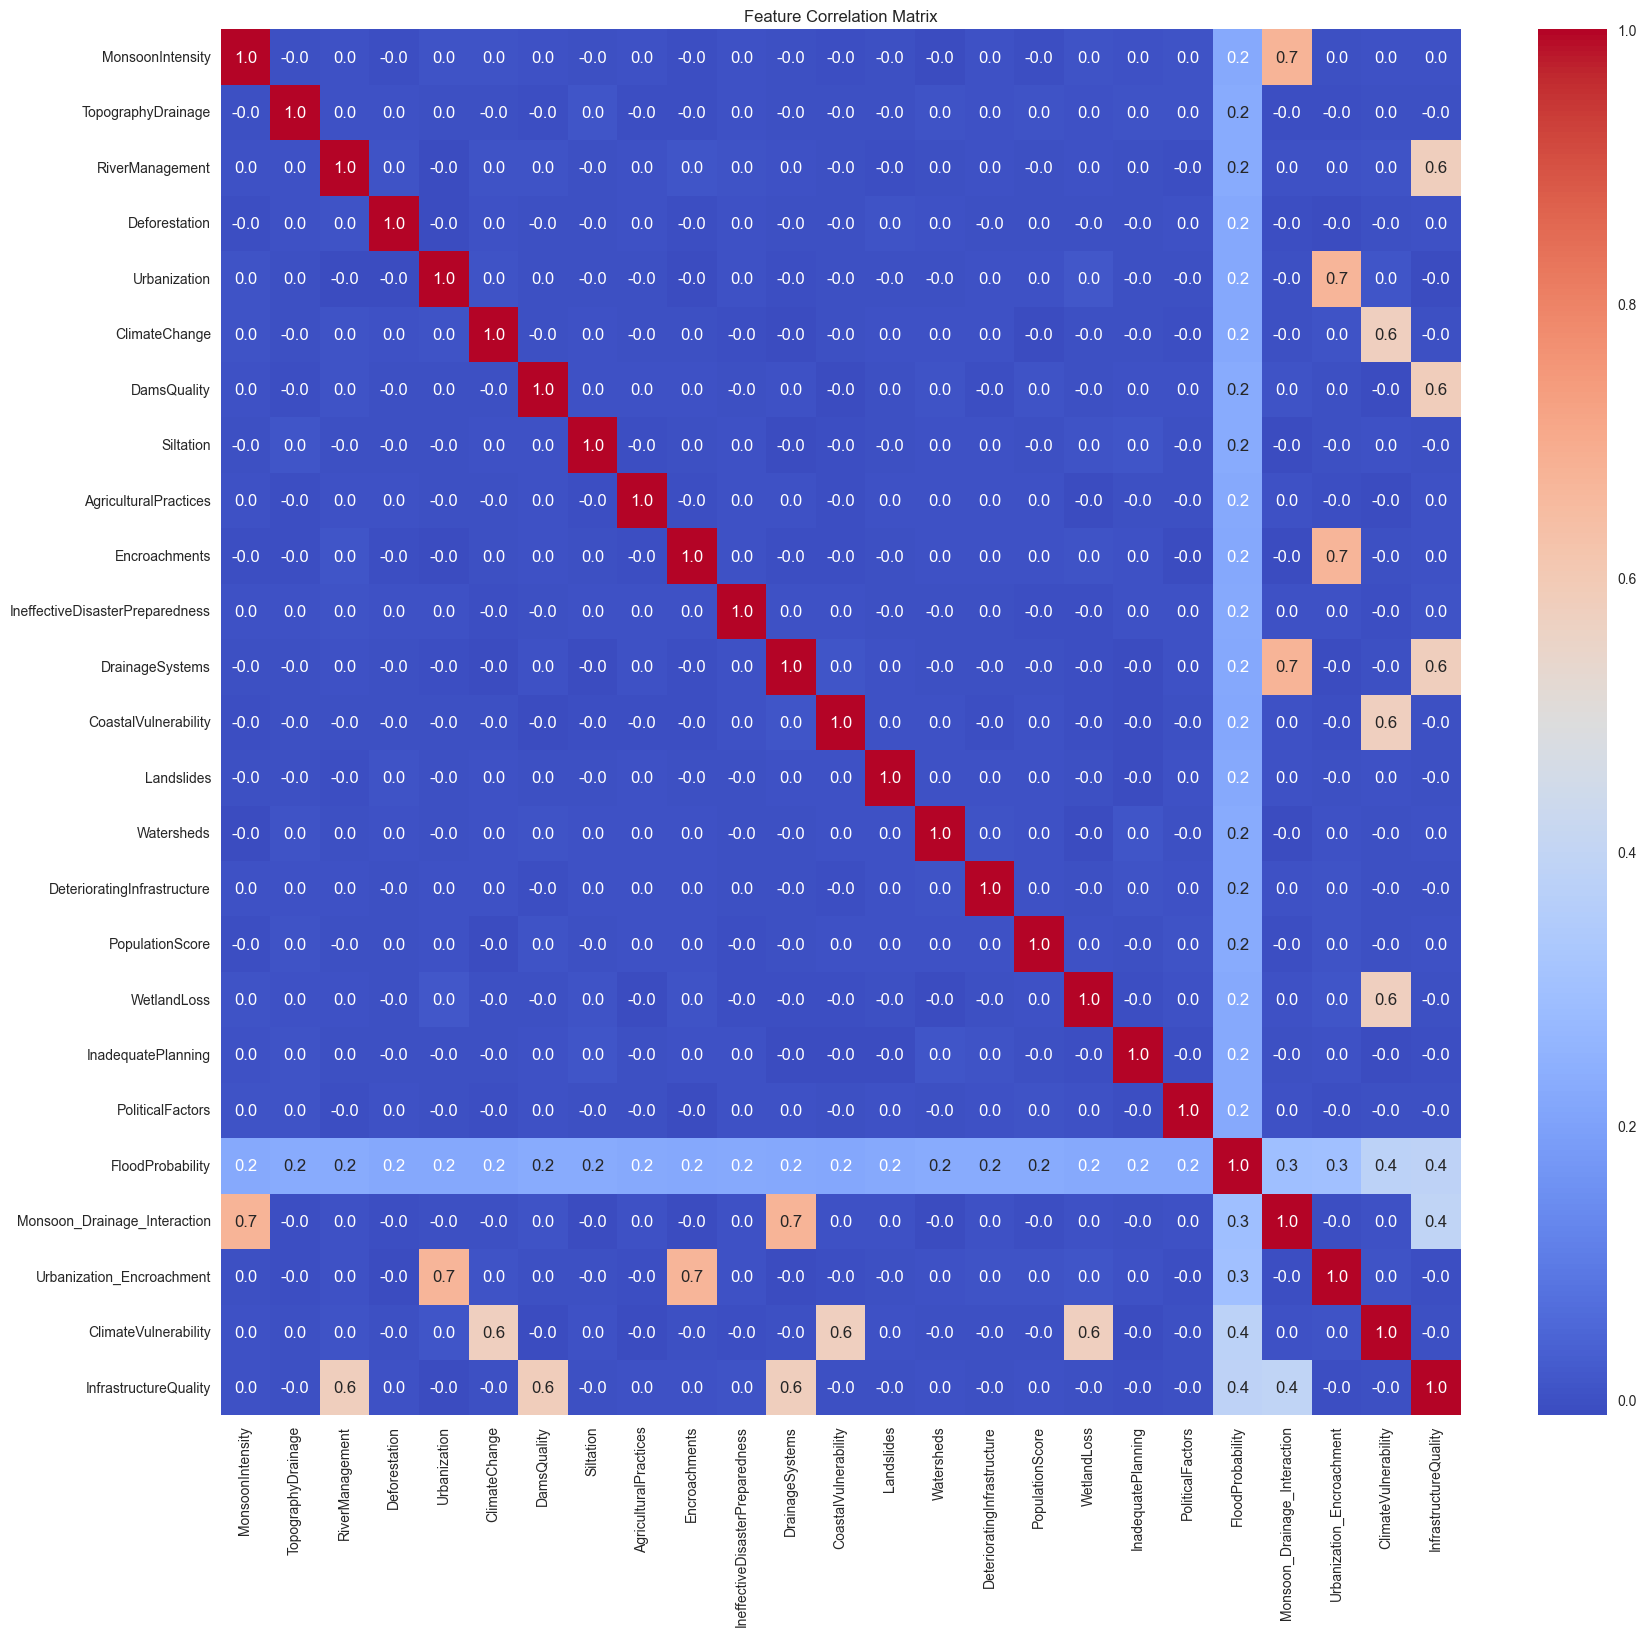

Top features by correlation:
 FloodProbability                1.000000
InfrastructureQuality           0.387482
ClimateVulnerability            0.382139
Urbanization_Encroachment       0.297995
Monsoon_Drainage_Interaction    0.296578
DeterioratingInfrastructure     0.229444
TopographyDrainage              0.229414
RiverManagement                 0.228917
Watersheds                      0.228152
DamsQuality                     0.227467
Name: FloodProbability, dtype: float64


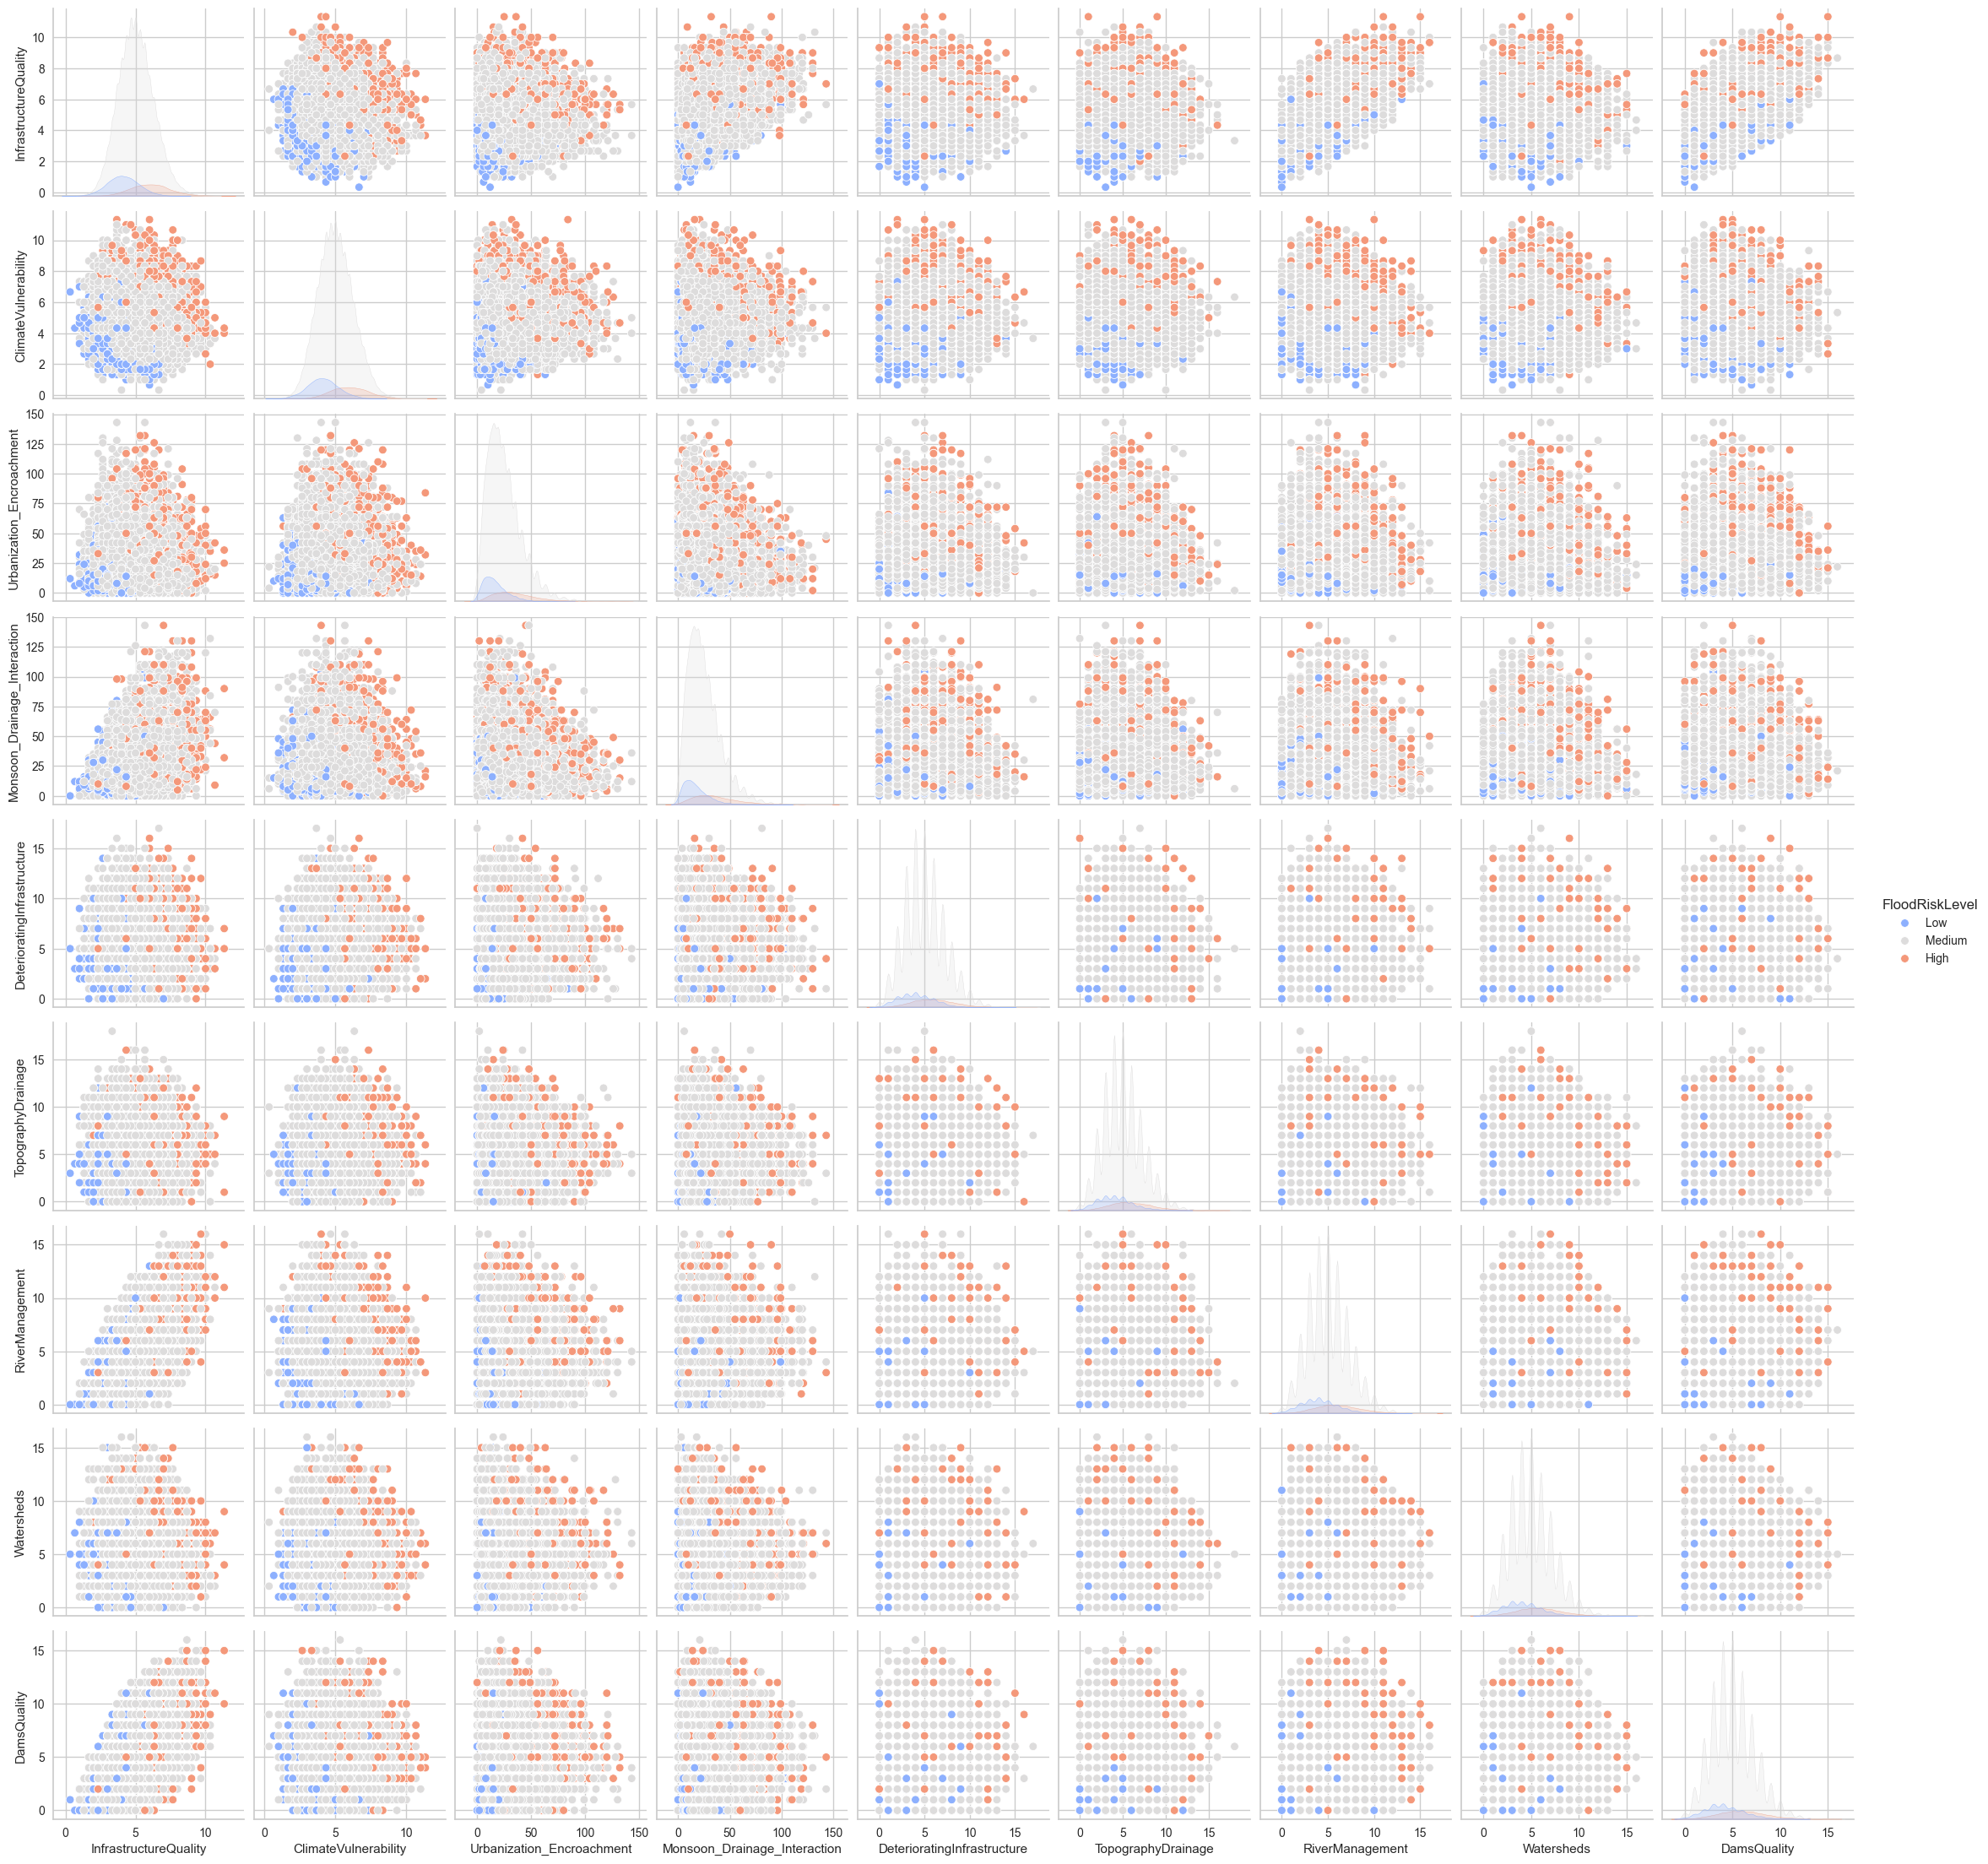

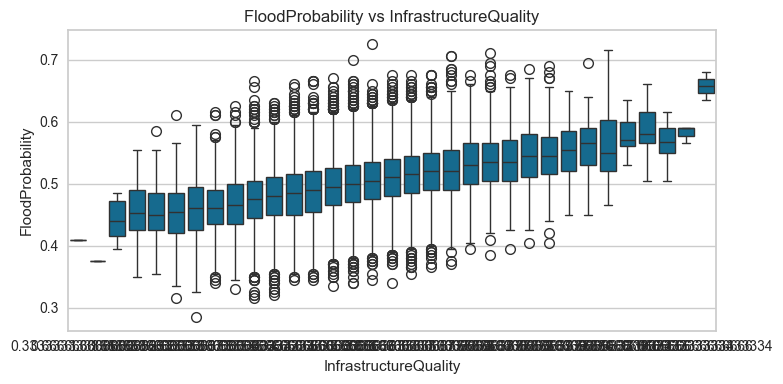

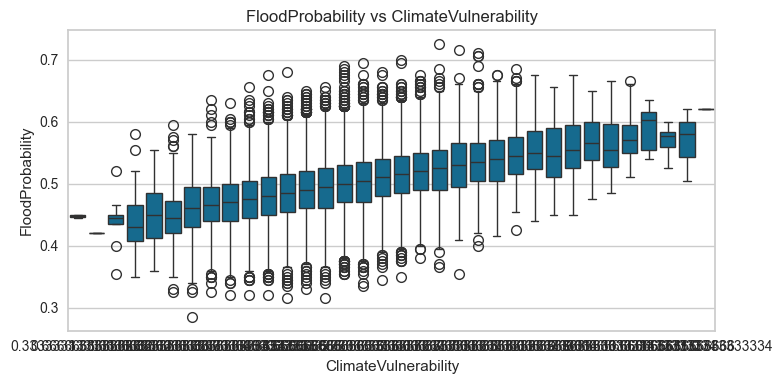

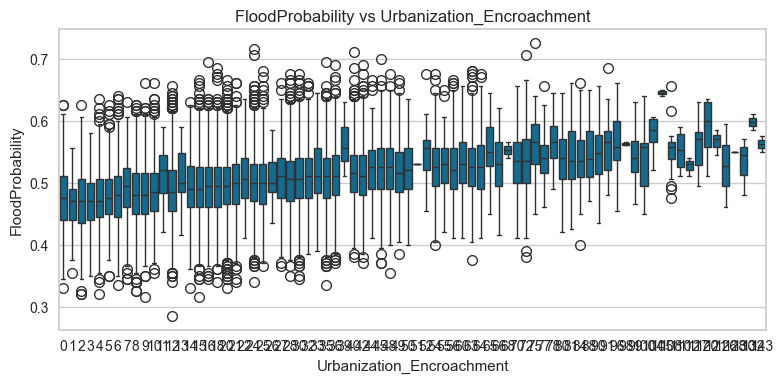

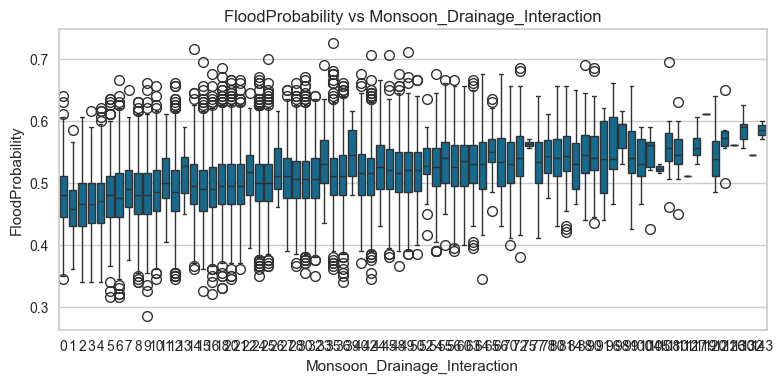

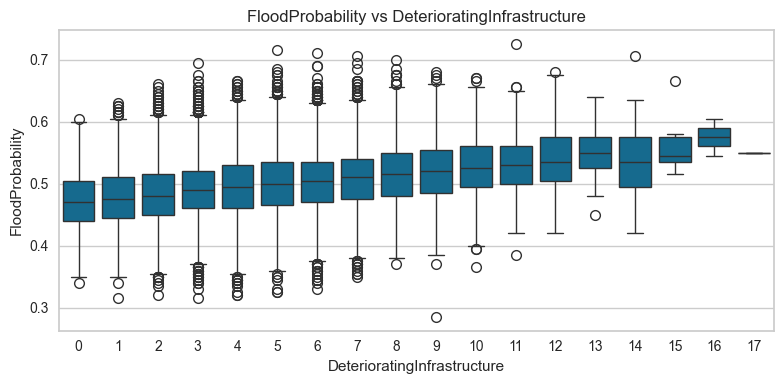

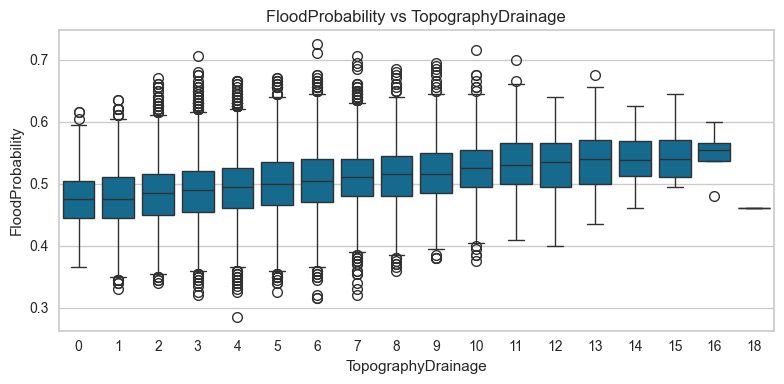

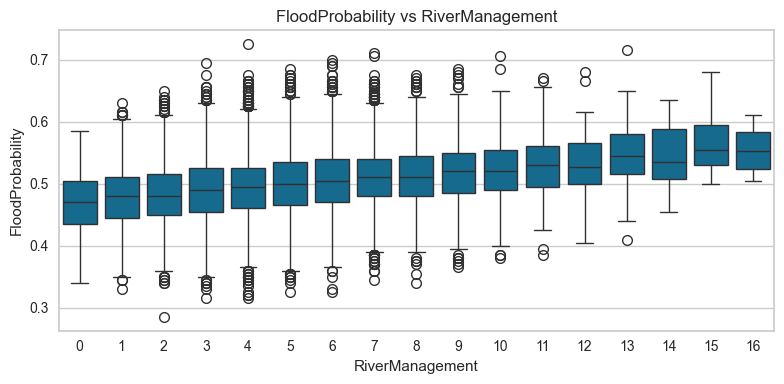

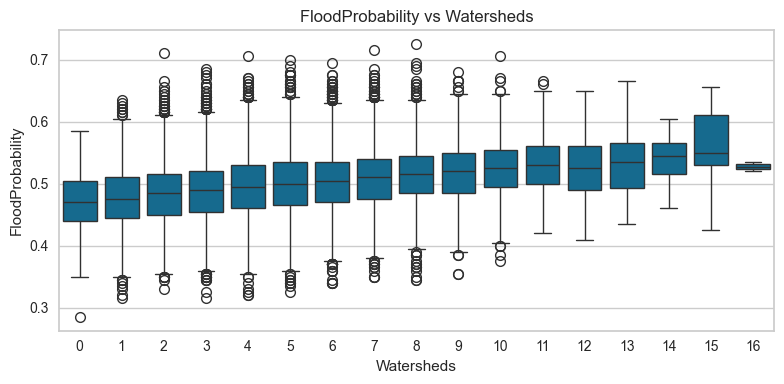

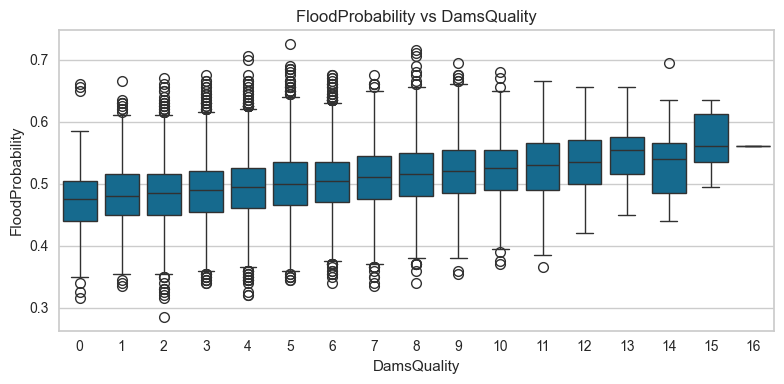

In [8]:
print("Dataset Description:\n")
#print(df.info())
print(df.describe())

# Check missing values
print("MISSING VALUES:\n", df.isnull().sum())

# Verify feature distributions
df.hist(figsize=(20, 15), bins=10)
plt.tight_layout()
plt.show()

# Visualize sampled target variable distribution
sns.kdeplot(df['FloodProbability'])
plt.figure(figsize=(10, 6))
plt.title('Target Variable Distribution')
plt.legend(['Flood Probability'])
plt.show()

# ====== CORRELATION ANALYSIS ======
plt.figure(figsize=(20, 18))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

target_corr = corr_matrix['FloodProbability'].abs().sort_values(ascending=False)
print("Top features by correlation:\n", target_corr.head(10))

# ======= PAIRPLOT ANALYSIS =======
# Limited to a few relevant features to avoid clutter
selected_cols = ['InfrastructureQuality', 'ClimateVulnerability', 'Urbanization_Encroachment', 'Monsoon_Drainage_Interaction','DeterioratingInfrastructure', 'TopographyDrainage','RiverManagement','Watersheds','DamsQuality']
df['FloodRiskLevel'] = pd.cut(df['FloodProbability'], bins=3, labels=["Low", "Medium", "High"])

sns.pairplot(df[selected_cols + ['FloodRiskLevel']], hue='FloodRiskLevel', palette='coolwarm')
plt.show()

# ======= BOXPLOT ANALYSIS =======

for feature in selected_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=feature, y='FloodProbability', data=df)
    plt.title(f'FloodProbability vs {feature}')
    plt.tight_layout()
    plt.show()

### 6. Model Selection & Baseline Comparisons


In [9]:
# Install and import pycaret if not already available


from pycaret.regression import setup, compare_models, pull

# PyCaret setup
s = setup(data=df, target='FloodProbability', session_id=5)
best = compare_models(sort='MAE', exclude=['lightgbm'])
results = pull()
print(results.iloc[0])

,Description,Value
0,Session id,5
1,Target,FloodProbability
2,Target type,Regression
3,Original data shape,"(50000, 26)"
4,Transformed data shape,"(50000, 28)"
5,Transformed train set shape,"(35000, 28)"
6,Transformed test set shape,"(15000, 28)"
7,Numeric features,24
8,Categorical features,1
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.7280
ridge,Ridge Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.2340
lar,Least Angle Regression,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1440
br,Bayesian Ridge,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.1990
huber,Huber Regressor,0.0001,0.0000,0.0002,1.0000,0.0001,0.0002,1.0720
rf,Random Forest Regressor,0.0167,0.0004,0.0205,0.8315,0.0136,0.0335,19.0350
et,Extra Trees Regressor,0.0167,0.0004,0.0205,0.8319,0.0136,0.0336,13.1450
gbr,Gradient Boosting Regressor,0.0171,0.0004,0.0208,0.8257,0.0139,0.0346,5.3500
knn,K Neighbors Regressor,0.0218,0.0008,0.0277,0.6931,0.0183,0.0431,0.5910
dt,Decision Tree Regressor,0.0264,0.0012,0.0339,0.5379,0.0226,0.0532,0.4490


Model       Linear Regression
MAE                       0.0
MSE                       0.0
RMSE                      0.0
R2                        1.0
RMSLE                     0.0
MAPE                      0.0
TT (Sec)                0.728
Name: lr, dtype: object


### 7. Model Comparisions with Realistic Algorithms

In [11]:


# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create individual models for realistic comparison
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Define the models with realistic performance
models_to_compare = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Results storage
comparison_results = []

# 5-fold cross-validation for robust evaluation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== REALISTIC MODEL COMPARISON ===\n")

for name, model in models_to_compare.items():
    print(f"Evaluating {name}...")
    
    # Time the training
    start_time = time.time()
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    cv_mae = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    cv_rmse = np.sqrt(-cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error'))
    
    # Fit on full training set for test predictions
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    training_time = time.time() - start_time
    
    # Test set metrics
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Store results
    comparison_results.append({
        'Model': name,
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'CV_MAE_Mean': cv_mae.mean(),
        'CV_RMSE_Mean': cv_rmse.mean(),
        'Test_R2': test_r2,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Training_Time': training_time
    })
    
    print(f"  Cross-Val R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  Training Time: {training_time:.2f}s\n")

# Convert to DataFrame for better visualization
results_df = pd.DataFrame(comparison_results)
print("=== DETAILED COMPARISON TABLE ===")
print(results_df.round(4))

=== REALISTIC MODEL COMPARISON ===

Evaluating Random Forest...
  Cross-Val R²: 0.7854 ± 0.0038
  Test R²: 0.7944
  Test MAE: 0.0177
  Training Time: 316.59s

Evaluating Extra Trees...
  Cross-Val R²: 0.7984 ± 0.0019
  Test R²: 0.8073
  Test MAE: 0.0172
  Training Time: 232.73s

Evaluating Gradient Boosting...
  Cross-Val R²: 0.8624 ± 0.0015
  Test R²: 0.8635
  Test MAE: 0.0144
  Training Time: 126.85s

=== DETAILED COMPARISON TABLE ===
               Model  CV_R2_Mean  CV_R2_Std  CV_MAE_Mean  CV_RMSE_Mean  \
0      Random Forest      0.7854     0.0038       0.0182        0.0232   
1        Extra Trees      0.7984     0.0019       0.0177        0.0225   
2  Gradient Boosting      0.8624     0.0015       0.0145        0.0186   

   Test_R2  Test_MAE  Test_RMSE  Training_Time  
0   0.7944    0.0177     0.0226       316.5875  
1   0.8073    0.0172     0.0219       232.7255  
2   0.8635    0.0144     0.0184       126.8494  


In [12]:


# Statistical significance testing between models
from scipy import stats

def compare_models_statistically(model1, model2, X, y, cv_folds=10):
    """Compare two models using paired t-test on cross-validation scores"""
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    scores1 = cross_val_score(model1, X, y, cv=cv, scoring='r2')
    scores2 = cross_val_score(model2, X, y, cv=cv, scoring='r2')
    
    # Paired t-test
    t_stat, p_value = stats.ttest_rel(scores1, scores2)
    
    return {
        'model1_mean': scores1.mean(),
        'model2_mean': scores2.mean(),
        'difference': scores1.mean() - scores2.mean(),
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': p_value < 0.05
    }

# Compare models pairwise
model_names = list(models_to_compare.keys())
print("=== STATISTICAL MODEL COMPARISON ===\n")

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        model1_name = model_names[i]
        model2_name = model_names[j]
        
        comparison = compare_models_statistically(
            models_to_compare[model1_name],
            models_to_compare[model2_name],
            X_train, y_train
        )
        
        print(f"{model1_name} vs {model2_name}:")
        print(f"  {model1_name} R²: {comparison['model1_mean']:.4f}")
        print(f"  {model2_name} R²: {comparison['model2_mean']:.4f}")
        print(f"  Difference: {comparison['difference']:.4f}")
        print(f"  P-value: {comparison['p_value']:.4f}")
        print(f"  Significant: {'Yes' if comparison['significant'] else 'No'}\n")

=== STATISTICAL MODEL COMPARISON ===

Random Forest vs Extra Trees:
  Random Forest R²: 0.7899
  Extra Trees R²: 0.8014
  Difference: -0.0115
  P-value: 0.0000
  Significant: Yes

Random Forest vs Gradient Boosting:
  Random Forest R²: 0.7899
  Gradient Boosting R²: 0.8628
  Difference: -0.0729
  P-value: 0.0000
  Significant: Yes

Extra Trees vs Gradient Boosting:
  Extra Trees R²: 0.8014
  Gradient Boosting R²: 0.8628
  Difference: -0.0614
  P-value: 0.0000
  Significant: Yes



In [13]:
# ...existing code...

# Optimize the best performing model
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Based on your results, let's optimize the top performer
best_model_name = results_df.loc[results_df['Test_R2'].idxmax(), 'Model']
print(f"Optimizing {best_model_name}...")

if best_model_name == 'Random Forest':
    param_distributions = {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(randint(5, 30).rvs(10)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['auto', 'sqrt', 'log2', None]
    }
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    
elif best_model_name == 'Extra Trees':
    param_distributions = {
        'n_estimators': randint(100, 500),
        'max_depth': [None] + list(randint(5, 30).rvs(10)),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['auto', 'sqrt', 'log2', None]
    }
    base_model = ExtraTreesRegressor(random_state=42, n_jobs=-1)
    
else:  # Gradient Boosting
    param_distributions = {
        'n_estimators': randint(100, 300),
        'learning_rate': uniform(0.01, 0.2),
        'max_depth': randint(3, 10),
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(1, 10),
        'subsample': uniform(0.6, 0.4)
    }
    base_model = GradientBoostingRegressor(random_state=42)

# Randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter optimization...")
random_search.fit(X_train, y_train)

print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

# Final model evaluation
best_model = random_search.best_estimator_
final_predictions = best_model.predict(X_test)
final_r2 = r2_score(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)

print(f"Optimized model test R²: {final_r2:.4f}")
print(f"Optimized model test MAE: {final_mae:.4f}")

Optimizing Gradient Boosting...
Starting hyperparameter optimization...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'learning_rate': 0.17309228569096685, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 4, 'n_estimators': 262, 'subsample': 0.9085081386743783}
Best cross-validation score: 0.9840
Optimized model test R²: 0.9852
Optimized model test MAE: 0.0048


=== TOP 10 MOST IMPORTANT FEATURES ===
                        feature  importance
22         ClimateVulnerability    0.145575
23        InfrastructureQuality    0.142848
21    Urbanization_Encroachment    0.088945
1            TopographyDrainage    0.052257
16              PopulationScore    0.051444
19             PoliticalFactors    0.051218
14                   Watersheds    0.050926
7                     Siltation    0.050764
13                   Landslides    0.050505
15  DeterioratingInfrastructure    0.050427


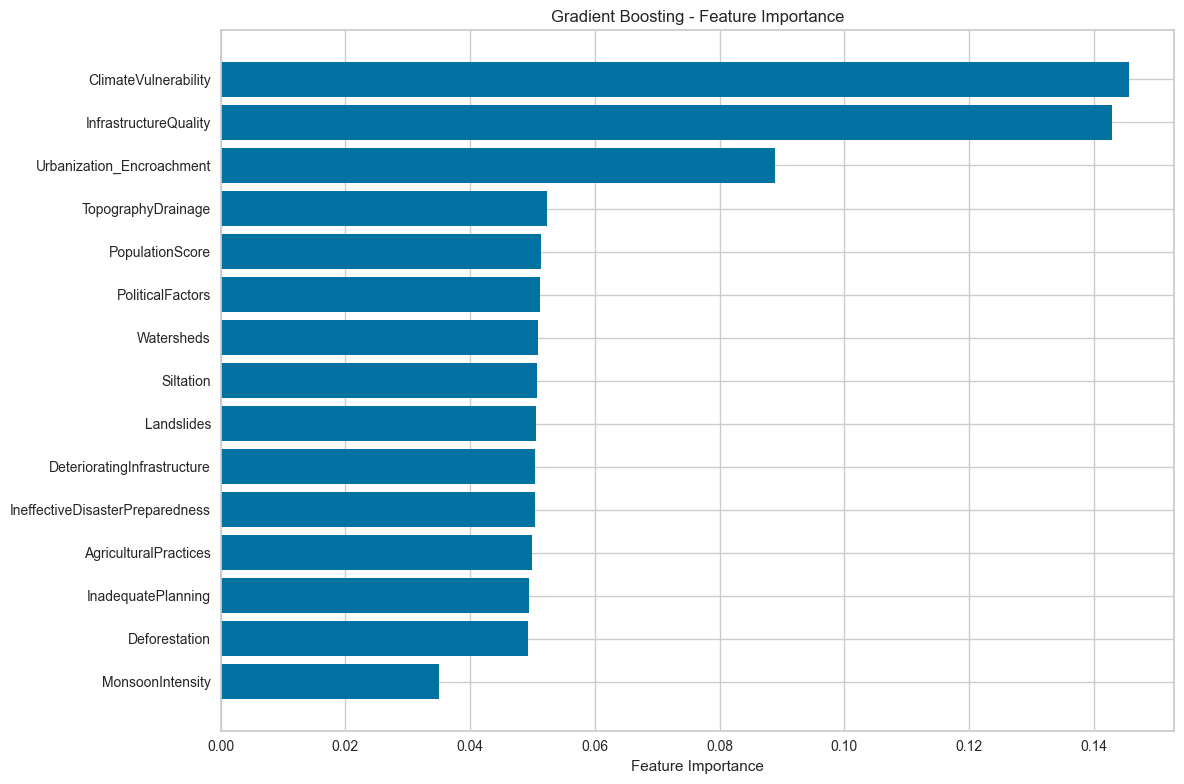

In [14]:


# Feature importance analysis
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("=== TOP 10 MOST IMPORTANT FEATURES ===")
    print(feature_importance.head(10))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'{best_model_name} - Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

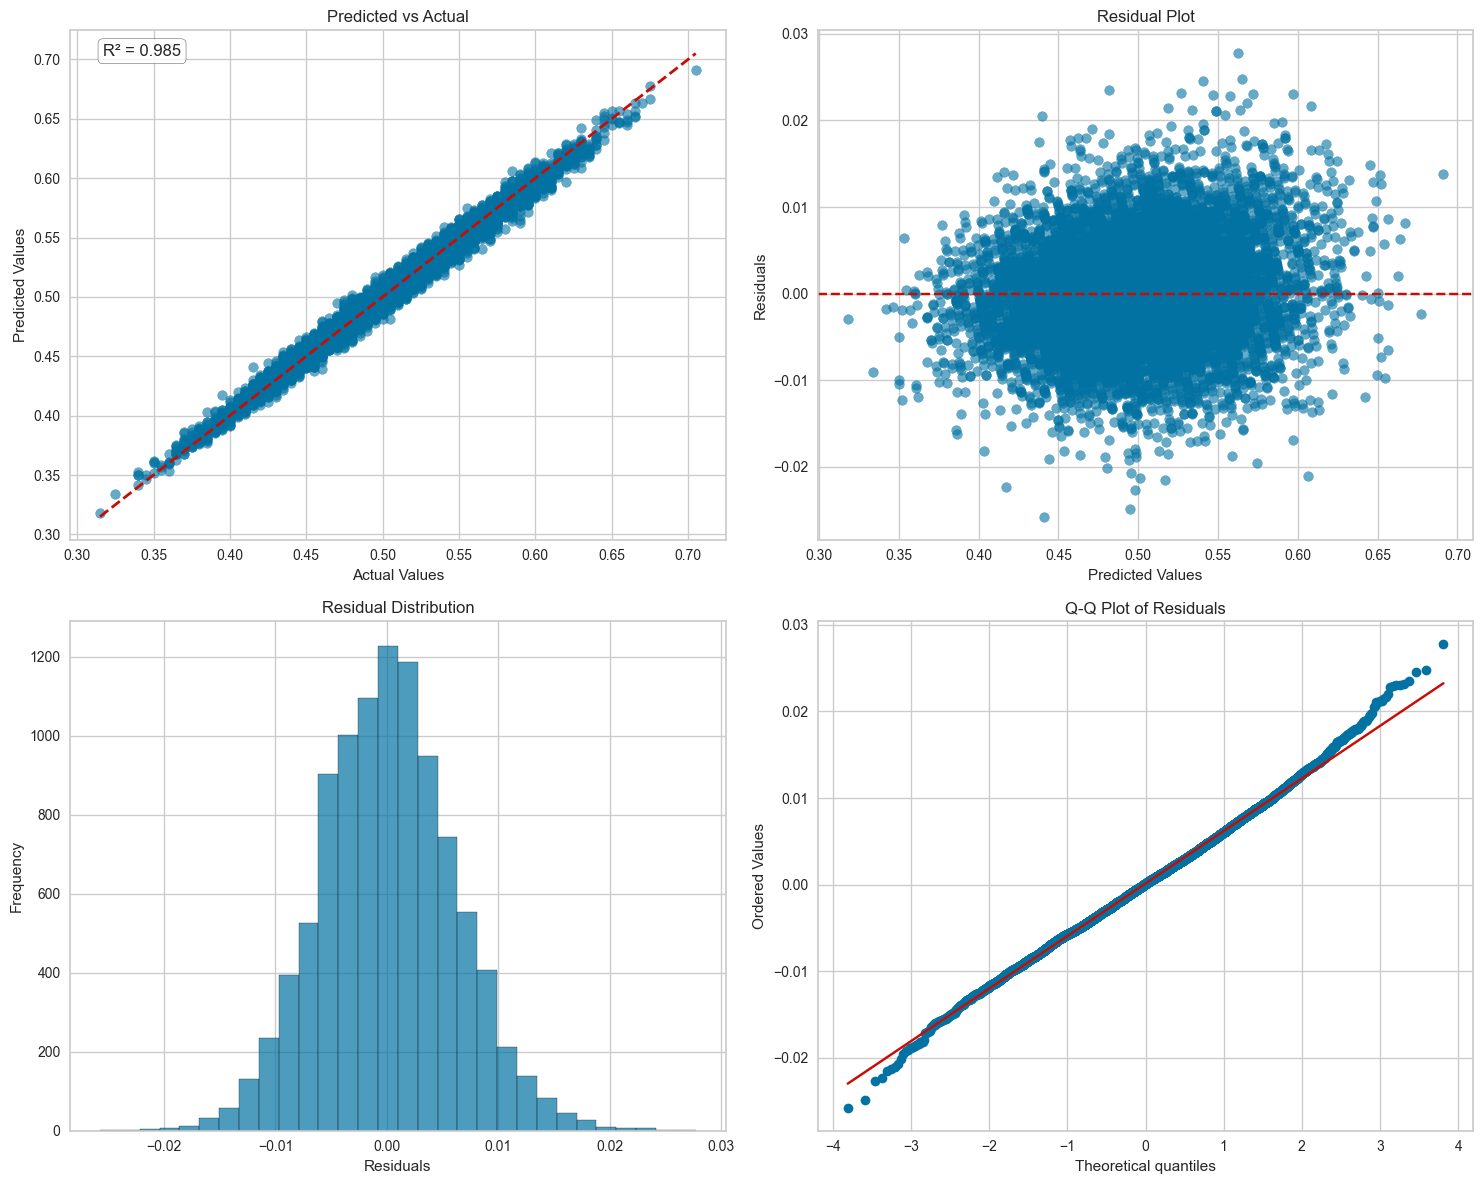

=== FINAL MODEL SUMMARY ===
Best Model: Gradient Boosting
Final Test R²: 0.9852
Final Test MAE: 0.0048
Final Test RMSE: 0.0061
Residual Mean: 0.000140
Residual Std: 0.0061


In [16]:


# Comprehensive model validation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, final_predictions, alpha=0.6)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title('Predicted vs Actual')
axes[0, 0].text(0.05, 0.95, f'R² = {final_r2:.3f}', transform=axes[0, 0].transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Residuals
residuals = y_test - final_predictions
axes[0, 1].scatter(final_predictions, residuals, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution')

# 4. Q-Q plot for normality
from scipy.stats import probplot
probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print(f"=== FINAL MODEL SUMMARY ===")
print(f"Best Model: {best_model_name}")
print(f"Final Test R²: {final_r2:.4f}")
print(f"Final Test MAE: {final_mae:.4f}")
print(f"Final Test RMSE: {np.sqrt(mean_squared_error(y_test, final_predictions)):.4f}")
print(f"Residual Mean: {residuals.mean():.6f}")
print(f"Residual Std: {residuals.std():.4f}")